First import our functions for data cleaning and variable creation.

In [59]:
# Import Functions
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import shapiro, pearsonr, spearmanr
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV


from src.dataCleaning import (
    load_data,
    filter_countries,
    filter_years,
    convert_numbers_from_scientific
)

from src.create_variables import (
    create_gdp_per_metrics,
    create_percentage_metrics
)



Then variables for the time period  and country to select data from are created and the variables to clean and gather data are called. 1990 was chosen as it's often the basis for comparison in climate action and 2022 was chosen as it's the latest date with GDP values in the dataset. 

In [ ]:
# Define Time Period and Country
start_year = 1990
end_year = 2022
country = "United Kingdom" 

# Load Data
co2 = load_data("data/owid-co2-data.csv")
energy = load_data("data//owid-energy-data.csv")

# Extract Data
co2 = filter_countries(co2, country)
energy = filter_countries(energy, country)

co2 = filter_years(co2, start_year, end_year)
energy = filter_years(energy, start_year, end_year)

# Merge Data
df = co2.merge(energy, on=["year","country","iso_code","population","gdp"])

# Drop Unnecessary Data to Speed up Processing
cols_to_drop = np.concatenate((df.columns[df.columns.str.contains("luc")], 
                               df.columns[df.columns.str.contains("cement")], 
                               df.columns[df.columns.str.contains("consumption")], 
                               df.columns[df.columns.str.contains("energy")], 
                               df.columns[df.columns.str.contains("cons")], 
                               df.columns[df.columns.str.contains("net")], 
                               df.columns[df.columns.str.contains("per_capita")], 
                               df.columns[df.columns.str.contains("low_carbon")], 
                               df.columns[df.columns.str.contains("prod")], 
                               df.columns[df.columns.str.contains("electricity_generation")], 
                               df.columns[df.columns.str.contains("electricity_demand")], 
                               df.columns[df.columns.str.contains("temperature")], 
                               df.columns[df.columns.str.contains("trade")], 
                               df.columns[df.columns.str.contains("global")], 
                               df.columns[df.columns.str.contains("cumulative")]))
df.drop(cols_to_drop, axis=1, inplace=True)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

           country  year iso_code  population           gdp         co2  \
0   United Kingdom  1990      GBR  57367867.0  1.505692e+12  601.945068   
1   United Kingdom  1991      GBR  57555199.0  1.488075e+12  609.412659   
2   United Kingdom  1992      GBR  57719273.0  1.491752e+12  593.845947   
3   United Kingdom  1993      GBR  57861037.0  1.527509e+12  579.612549   
4   United Kingdom  1994      GBR  58003200.0  1.585373e+12  574.016907   
5   United Kingdom  1995      GBR  58154632.0  1.623858e+12  566.158935   
6   United Kingdom  1996      GBR  58298563.0  1.663447e+12  586.760681   
7   United Kingdom  1997      GBR  58447091.0  1.713865e+12  562.708130   
8   United Kingdom  1998      GBR  58626822.0  1.766620e+12  568.543701   
9   United Kingdom  1999      GBR  58838663.0  1.823342e+12  561.649597   
10  United Kingdom  2000      GBR  59057333.0  1.889565e+12  569.033691   
11  United Kingdom  2001      GBR  59288095.0  1.939268e+12  577.970581   
12  United Kingdom  2002 

In [3]:
# Create Variables
df = create_gdp_per_metrics(df)
df = create_percentage_metrics(df, "co2_per_gdp")
df = create_percentage_metrics(df, "co2")
df = create_percentage_metrics(df, "gdp")

df = convert_numbers_from_scientific(df, "gdp")


Plot to show how GDP has changed, mention financial crisis and covid.

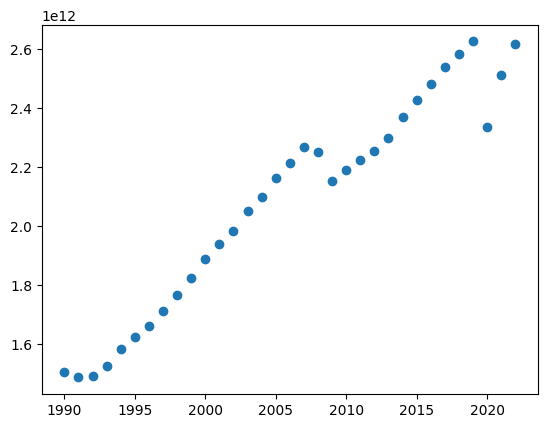

In [4]:
plt.scatter(df["year"], df["gdp"])
plt.show()

Plot to show how economic growth and carbon emissions have absolutely decoupled (emissions intensity and co2 vs gdp) Work out percentage decrease/increase of each.

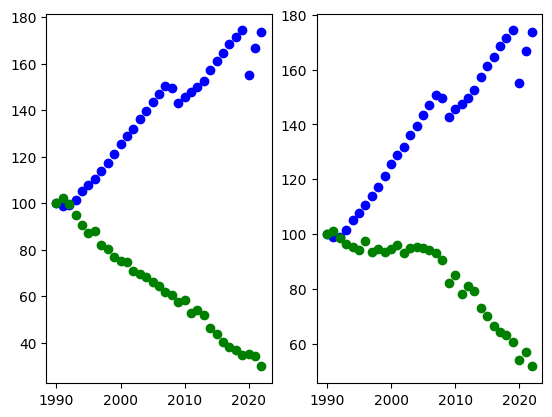

In [ ]:

fig, axs = plt.subplots(1,2)

axs[0].scatter(df["year"], df["gdp_percent_1990"], c="b", label="GDP, 100% = 1990")
axs[0].scatter(df["year"], df["co2_per_gdp_percent_1990"], c = "g", label="Emissions Intensity, 100% = 1990")

axs[1].scatter(df["year"], df["gdp_percent_1990"], c="b", label="GDP, 100% = 1990")
axs[1].scatter(df["year"], df["co2_percent_1990"], c = "g", label="CO2, 100% = 1990")

## carbon intensity elec
## coal, oil, flaring co2, otherindustry
## total_ghg_emissions, co2, methane, nitrous_oxide

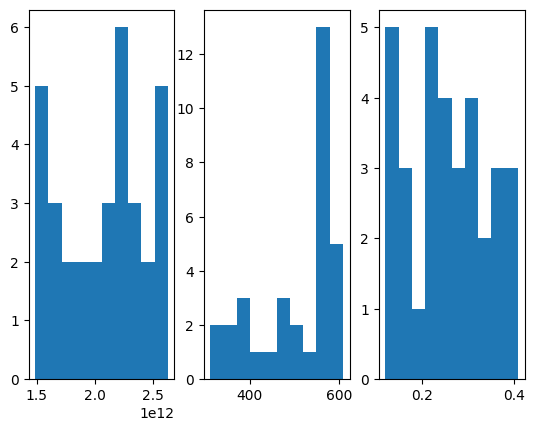

ShapiroResult(statistic=0.9368274002509965, pvalue=0.05496208742870383)
ShapiroResult(statistic=0.8438643766918591, pvalue=0.00025018120193819363)
ShapiroResult(statistic=0.958623852933202, pvalue=0.23626128678973968)


In [6]:
fig, axs = plt.subplots(1,3)
axs[0].hist(df["gdp"],)
axs[1].hist(df["co2"])
axs[2].hist(df["co2_per_gdp"])
plt.show()
print(shapiro(df["gdp"]))
print(shapiro(df["co2"]))
print(shapiro(df["co2_per_gdp"]))

As Co2 isn't normally distributed, use Spearmans Rho for that and PearsonsR for other

In [7]:
corr, p = pearsonr(df["gdp"], df["co2_per_gdp"])
print(f"Pearsons Correlation: {corr}, p value: {p}")

corr, p = spearmanr(df["gdp"], df["co2"])
print(f"Spearmans Correlation: {corr}, p value: {p}")

Pearsons Correlation: -0.979914694575124, p value: 2.8422480551370183e-23
Spearmans Correlation: -0.9107620320855615, p value: 1.9182610230910563e-13


Strong negative correlation between GDP and emissions intensity, expect a strong one because emissions_intensity is based on GDP to calculate. But a similarly strong correlation in CO2 and GDP lends merit to the absolute decoupling of GDP and CO2.

How has energy mix changed over time
Renewables now equate for this much of the energy production, risen by this much, fossil fuels down by this much.
What percentage of that is each renewable energy source responsible for

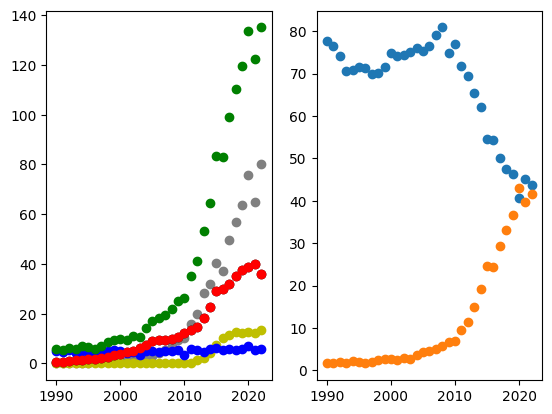

In [8]:
fig, axs = plt.subplots(1,2)
axs[0].scatter(df["year"], df["wind_electricity"], c="grey")
axs[0].scatter(df["year"], df["solar_electricity"], c="y")
axs[0].scatter(df["year"], df["biofuel_electricity"], c="black")
axs[0].scatter(df["year"], df["hydro_electricity"], c="b")
axs[0].scatter(df["year"], df["other_renewable_electricity"], c="r")
axs[0].scatter(df["year"], df["renewables_electricity"], c="g")

axs[1].scatter(df["year"], df["fossil_share_elec"])
axs[1].scatter(df["year"], df["renewables_share_elec"])




ShapiroResult(statistic=0.7435538086259941, pvalue=3.2017681514467406e-06)

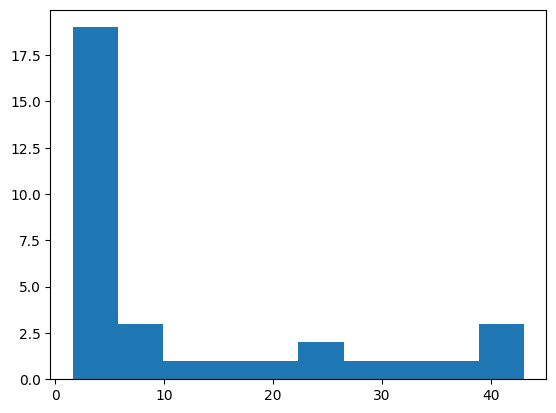

In [9]:
plt.hist(df["renewables_share_elec"])
shapiro(df["renewables_share_elec"])

Not normally distributed so use Spearmans Rho

In [10]:
corr, p = spearmanr(df["renewables_share_elec"], df["co2_per_gdp"])
print(f"Spearmans Correlation: {corr}, p value: {p}")
corr, p = spearmanr(df["renewables_share_elec"], df["co2"])
print(f"Spearmans Correlation: {corr}, p value: {p}")


Spearmans Correlation: -0.9879679144385028, p value: 1.0673873030746159e-26
Spearmans Correlation: -0.9431818181818182, p value: 2.2032038888664077e-16


Shows a strong negative correlation between renewables and emissions, same for CO2 and renewables.

Start with linear regression so we can see how the variables change when others are added - what does adding the other variables account for

To see what degree the changing energy mix is responsible for this decrease vs other factors, we will do a multiple linear regression. Since the dataset consists of only 33 datapoints, only a few predictor variables will be used.

Do two, how does the changing structure, i.e. energy mix account for emissions intensity and how do changes in actual energy production relate to emissions intensity.

1. Renewable Share
2. Fossil share
3. Year (to account for yearly trends)

<Axes: >

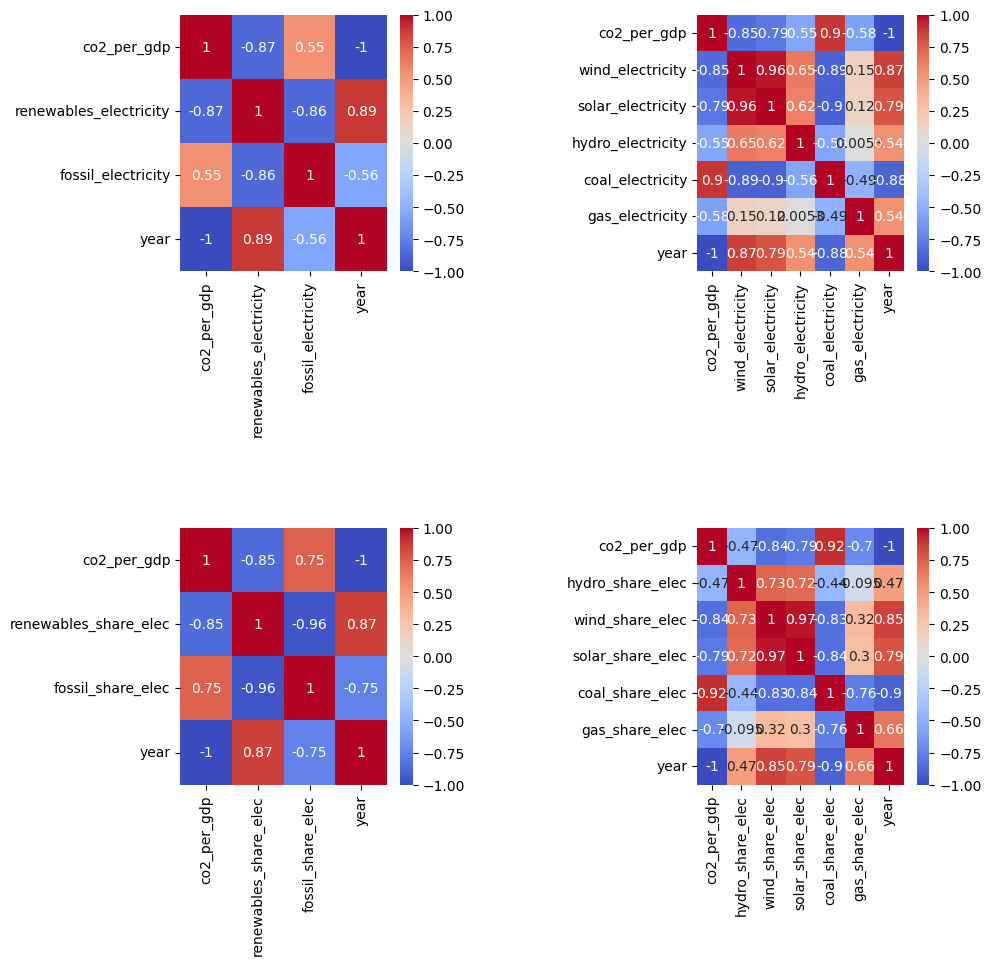

In [47]:
df_mlr = df[["co2_per_gdp", "wind_electricity", "solar_electricity", "hydro_electricity", "coal_electricity", "gas_electricity", "year"]]

fig, axs = plt.subplots(2,2)
fig.set_figheight(10)
fig.set_figwidth(10)
fig.subplots_adjust(hspace= 1, wspace = 1)

corr_matrix = df_mlr.corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    ax=axs[0,1])

df_mlr = df[["co2_per_gdp", "renewables_electricity", "fossil_electricity", "year"]]

corr_matrix = df_mlr.corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    ax=axs[0,0])

df_mlr = df[["co2_per_gdp", "hydro_share_elec", "wind_share_elec", "solar_share_elec", "coal_share_elec", "gas_share_elec", "year"]]

corr_matrix = df_mlr.corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    ax=axs[1,1])

df_mlr = df[["co2_per_gdp", "renewables_share_elec", "fossil_share_elec", "year"]]

corr_matrix = df_mlr.corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    ax=axs[1,0])

However, every value in both multiple linear regressions are highly correlated with one-another, even when splitting the factors into multiple parts or dropping less relevant factors. This makes it unsuitable for understanding to what degree the energy mix is responsible for carbon decoupling. Because of this we will instead use a ridge regression. In the above we can also see that the share produces a more linear relationship than just raw electricity produced, therefore the it's the one I'll use.


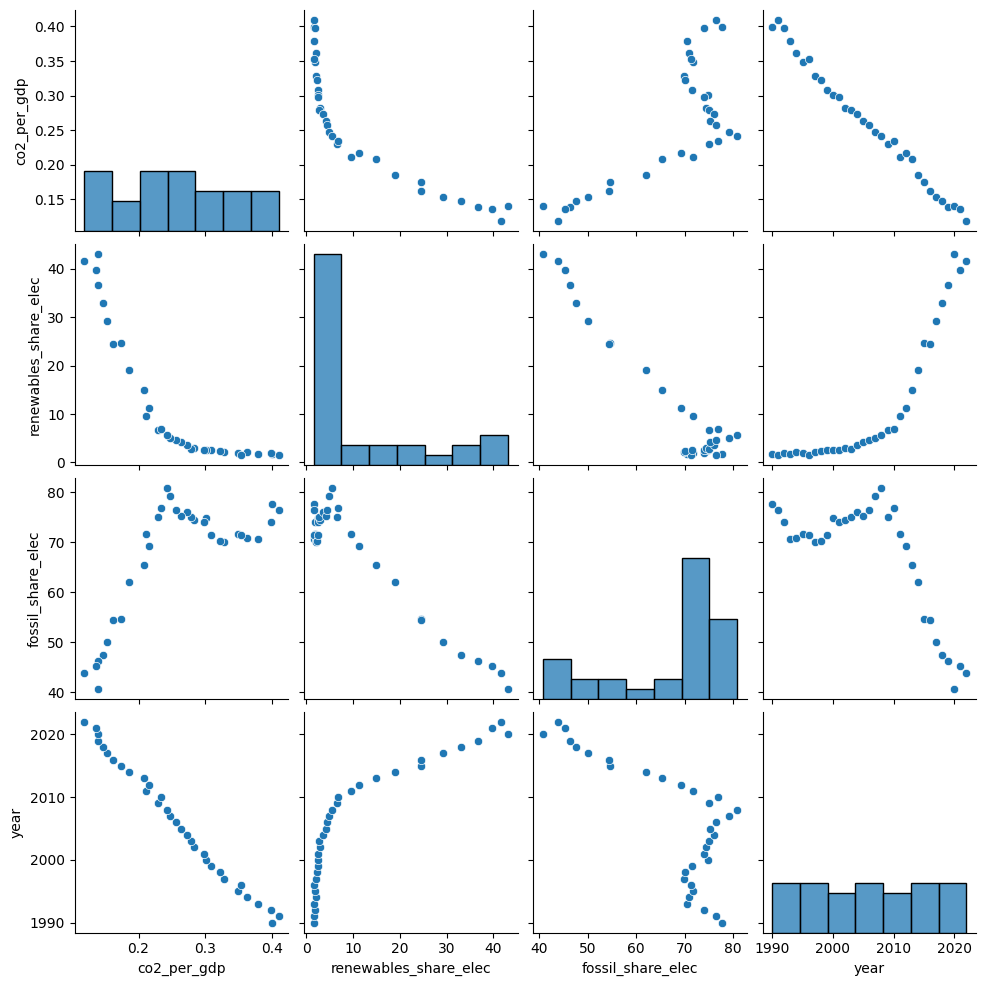

In [55]:
df_rr = df[["co2_per_gdp", "renewables_share_elec", "fossil_share_elec", "year"]]
sns.pairplot(df_rr)

Fossil fuels share is the most dubious but with a correlation coefficient of 0.75 I'm happy to include it.